In [1]:
import numpy as np
import pandas as pd
import seaborn as sns

np.set_printoptions(suppress=True)

import os
import scanpy as sc
import matplotlib.pyplot as plt

%reload_ext autoreload
%autoreload 2

In [2]:
adata = sc.read_h5ad('../datasets/Mouse_Hematopoiesis/adata_used.h5ad')
adata

AnnData object with n_obs × n_vars = 44756 × 5000
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'meta_clones'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'Time_point_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'meta_clones_colors', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [4]:
adata.var_names_make_unique()
adata = adata[adata.obs['meta_clones'] != '-1.0', :]
idx_mt = [not gene.startswith('mt-') for gene in adata.var.index]
adata = adata[:, idx_mt]
adata

View of AnnData object with n_obs × n_vars = 44756 × 4995
    obs: 'Time_point', 'Population', 'Annotation', 'Well', 'time_cat', 'leiden', 'comb', 'label_man', 'clones', 'meta_clones'
    var: 'symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'Annotation_colors', 'Time_point_colors', 'comb_colors', 'hvg', 'label_man_colors', 'label_man_sizes', 'leiden', 'leiden_colors', 'log1p', 'meta_clones_colors', 'neighbors', 'paga', 'pca', 'time_cat_colors', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [5]:
adata_hsc = adata[adata.obs['label_man'] == 'prog_1', :]
adata_hsc.shape

(1595, 4995)

In [6]:
test = adata_hsc[adata_hsc.obs['meta_clones'].values == str(8), :]
refe = adata_hsc[adata_hsc.obs['meta_clones'].values != str(8), :]

/tmp/ipykernel_2800900/49590656.py:6: RuntimeWarning: divide by zero encountered in divide
  fold_change = mean_test / mean_refe
/tmp/ipykernel_2800900/49590656.py:6: RuntimeWarning: invalid value encountered in divide
  fold_change = mean_test / mean_refe
/tmp/ipykernel_2800900/49590656.py:7: RuntimeWarning: divide by zero encountered in log2
  lfc = np.array(np.log2(fold_change)).squeeze()


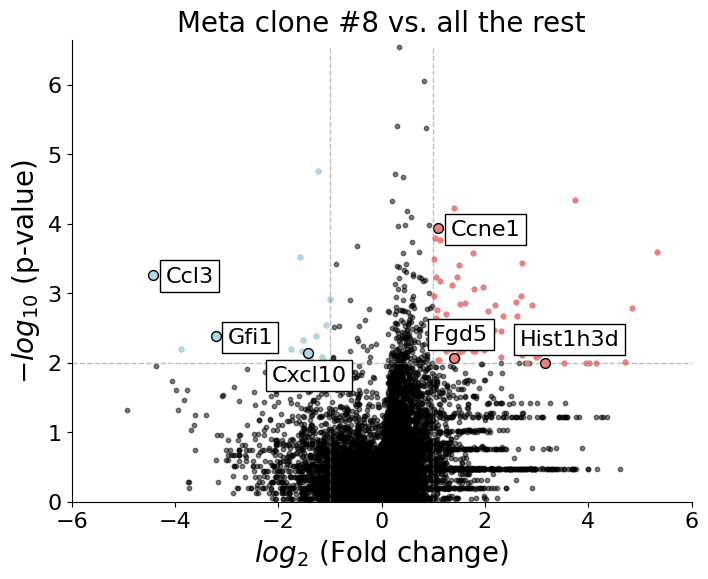

In [7]:
from scipy import stats

mean_test = np.mean(np.exp(test.raw.X.todense()) - 1, axis=0)
mean_refe = np.mean(np.exp(refe.raw.X.todense()) - 1, axis=0)

fold_change = mean_test / mean_refe
lfc = np.array(np.log2(fold_change)).squeeze()

t_statistic, p_values = stats.mannwhitneyu(test.raw.X.todense(), refe.raw.X.todense())
neg_log_10 = -np.log10(p_values)
threshold = 0.01

fig, axes = plt.subplots(1, 1, figsize=(8, 6))
plt.hlines(y=-np.log10(0.01), linestyles='dashed', xmin=-6, xmax=6, color='grey', alpha=0.5, linewidth=1)
plt.scatter(lfc, neg_log_10, color='black', alpha=0.5, s=10)
plt.xlim([-6, 6])
plt.ylim([0, np.nanmax(neg_log_10) + 0.1])
plt.xticks(fontsize=16)
plt.yticks(fontsize=16)

plt.vlines(x=-1, linestyles='dashed', ymin=0, ymax=np.nanmax(neg_log_10), color='grey', alpha=0.5, linewidth=1)
plt.vlines(x=1, linestyles='dashed', ymin=0, ymax=np.nanmax(neg_log_10), color='grey', linewidth=1, alpha=0.5)
plt.scatter(lfc[np.bitwise_and(lfc > 1, p_values < threshold)], neg_log_10[np.bitwise_and(lfc > 1, p_values < threshold)], color='lightcoral', s=10)
plt.scatter(lfc[np.bitwise_and(lfc < -1, p_values < threshold)], neg_log_10[np.bitwise_and(lfc < -1, p_values < threshold)], color='lightblue', s=10)


index = [19790, 19791, 4291, 7532, 12185, 12223]
names = ['Robo1', 'Robo2', 'Ccne1', 'Fgd5', 'Hist1h1a', 'Hist1h3d']

for i in range(6):
    plt.scatter(lfc[index[i]],neg_log_10[index[i]], color='lightcoral',edgecolors='k', s=50)


t = plt.text(lfc[4291] + 0.25, neg_log_10[4291] - 0.1, 'Ccne1', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[7532] - 0.4, neg_log_10[7532] +0.25 , 'Fgd5', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[12223] - 0.5, neg_log_10[12223] +0.25 , 'Hist1h3d', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))


# ###

index = [4272, 5559, 8053]
names = ['Ccl3', 'Cxcl10', 'Gfi1']

for i in range(3):
    plt.scatter(lfc[index[i]],neg_log_10[index[i]], color='lightblue',edgecolors='k', s=50)

t = plt.text(lfc[4272] + 0.25, neg_log_10[4272] -0.1, 'Ccl3', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[5559] - 0.7, neg_log_10[5559] - 0.41, 'Cxcl10', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))

t = plt.text(lfc[8053] + 0.22, neg_log_10[8053] -0.1, 'Gfi1', fontsize=16)
t.set_bbox(dict(facecolor='white', alpha=1))


axes.spines['top'].set_visible(False)
axes.spines['right'].set_visible(False)

plt.xlabel('$log_{2}$ (Fold change)', fontsize=20)
plt.grid(False)
plt.ylabel('$-log_{10}$ (p-value)', fontsize=20)
plt.title('Meta clone #8 vs. all the rest', fontsize=20)

plt.savefig('./de_mouse_mc8_vs_rest.svg', bbox_inches='tight', transparent=True, dpi=300)

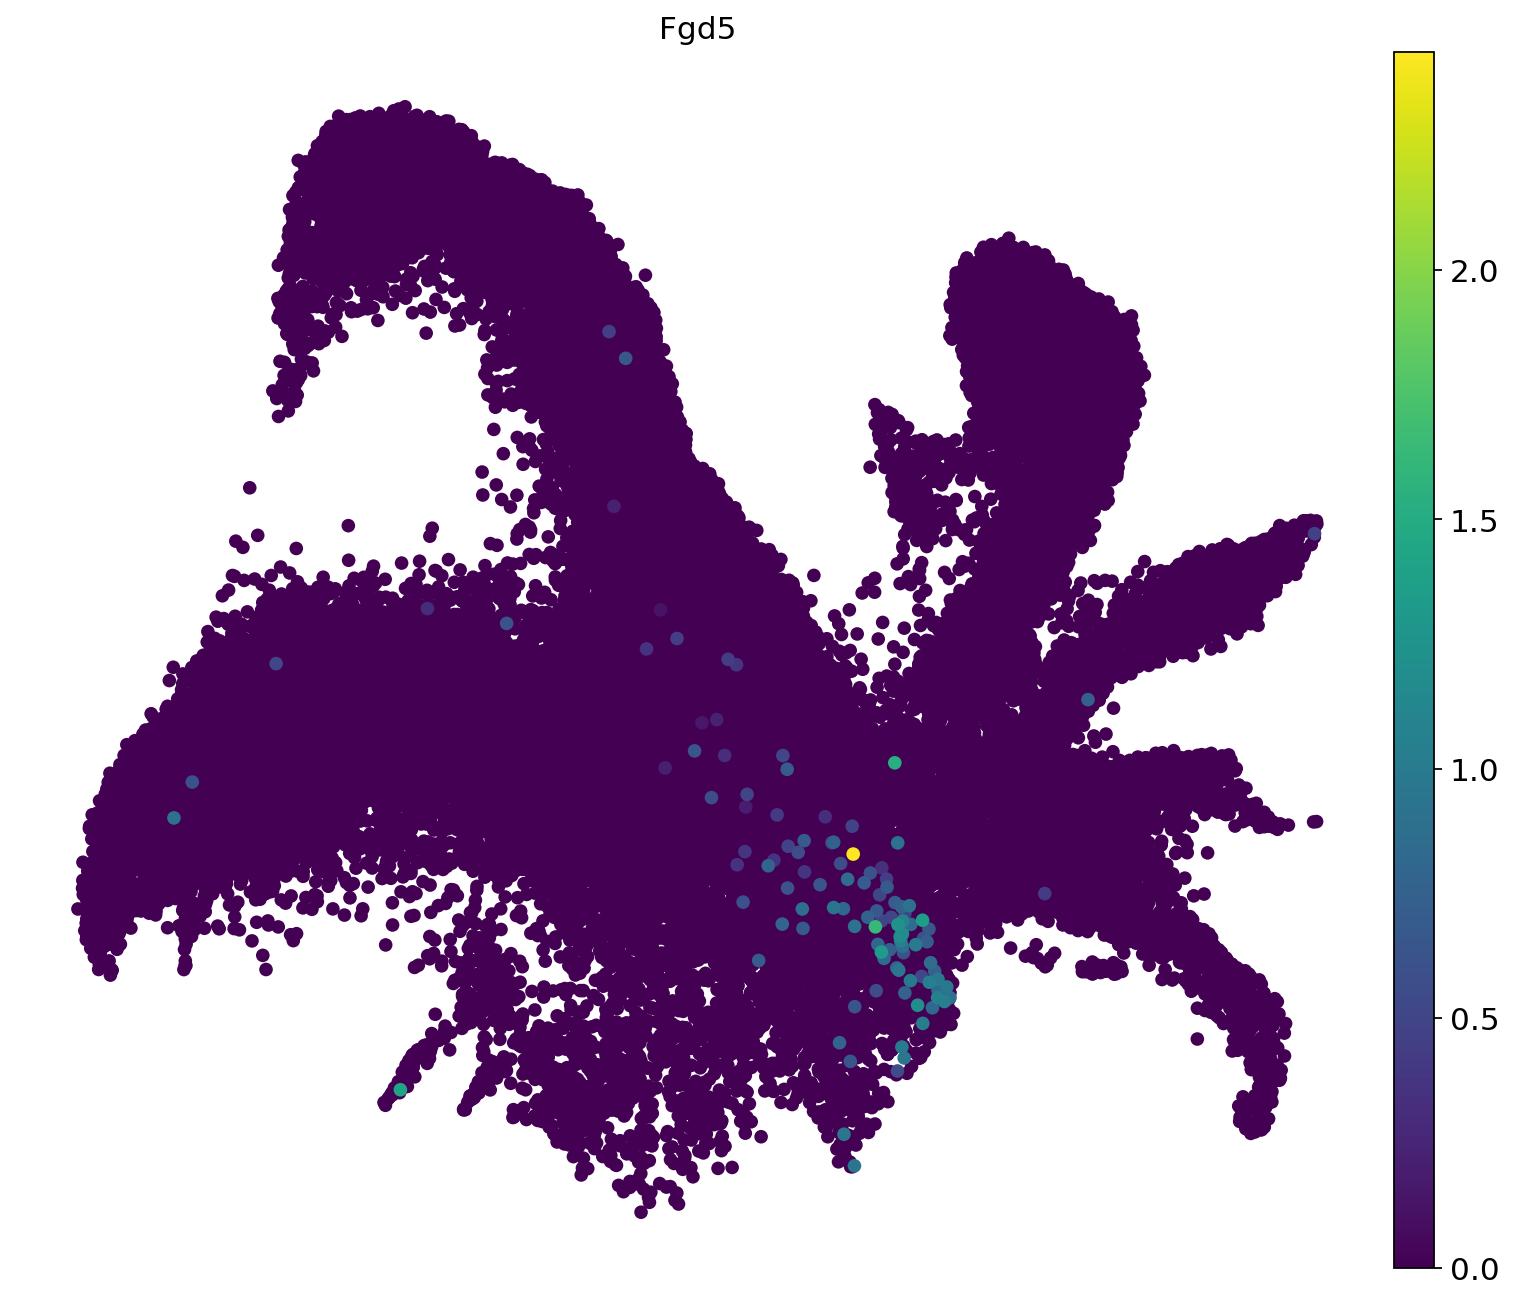

In [8]:
sc.set_figure_params(dpi_save=300, figsize=(12, 10), transparent=True)
sc.pl.umap(adata, color=['Fgd5'], frameon=False, size=150, title='Fgd5', save='_Fgd5.pdf')